# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3021s 18us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

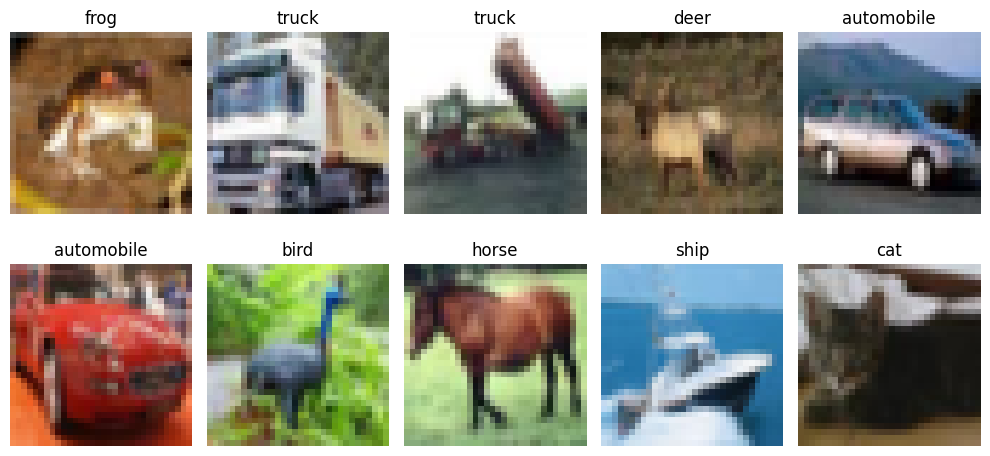

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [7]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
# ANN Model

from tensorflow.keras.callbacks import EarlyStopping

# Build ANN
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

# Compile Model
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train Model
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.2423 - loss: 2.0376 - val_accuracy: 0.3190 - val_loss: 1.8928
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2999 - loss: 1.9065 - val_accuracy: 0.3358 - val_loss: 1.8222
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3145 - loss: 1.8583 - val_accuracy: 0.3676 - val_loss: 1.7887
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3292 - loss: 1.8259 - val_accuracy: 0.3610 - val_loss: 1.8115
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3373 - loss: 1.8080 - val_accuracy: 0.3594 - val_loss: 1.7781
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3467 - loss: 1.7884 - val_accuracy: 0.3786 - val_loss: 1.7508
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3526 - loss: 1.7735 - val_accuracy: 0.3834 - val_loss: 1.7250
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3560 - loss: 1.7666 - val_accuracy: 0

In [9]:

# Evaluate Model
ann_test_loss, ann_test_acc = ann_model.evaluate(
    x_test_flat,
    y_test,
    verbose=0
)

print(f"\nANN Test Accuracy : {ann_test_acc:.4f}")
print(f"ANN Test Loss     : {ann_test_loss:.4f}")


ANN Test Accuracy : 0.4371
ANN Test Loss     : 1.6177


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [10]:
# CNN Model

from tensorflow.keras.callbacks import EarlyStopping

cnn_model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    # Classification
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.3502 - loss: 1.8052 - val_accuracy: 0.4596 - val_loss: 1.5030
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4806 - loss: 1.4344 - val_accuracy: 0.4678 - val_loss: 1.7068
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5647 - loss: 1.2262 - val_accuracy: 0.5096 - val_loss: 1.6251
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6205 - loss: 1.0810 - val_accuracy: 0.6764 - val_loss: 0.8946
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6551 - loss: 0.9913 - val_accuracy: 0.7070 - val_loss: 0.8382
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6840 - loss: 0.9207 - val_accuracy: 0.7412 - val_loss: 0.7441
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7028 - loss: 0.8618 - val_accuracy: 0.7032 - val_loss: 1.0113
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7188 - loss: 0.8202 - val_accuracy:

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print(f"\nCNN Test Accuracy : {cnn_test_acc:.4f}")
print(f"CNN Test Loss     : {cnn_test_loss:.4f}")


CNN Test Accuracy : 0.8064
CNN Test Loss     : 0.5694


## 📈 Compare Learning Curves

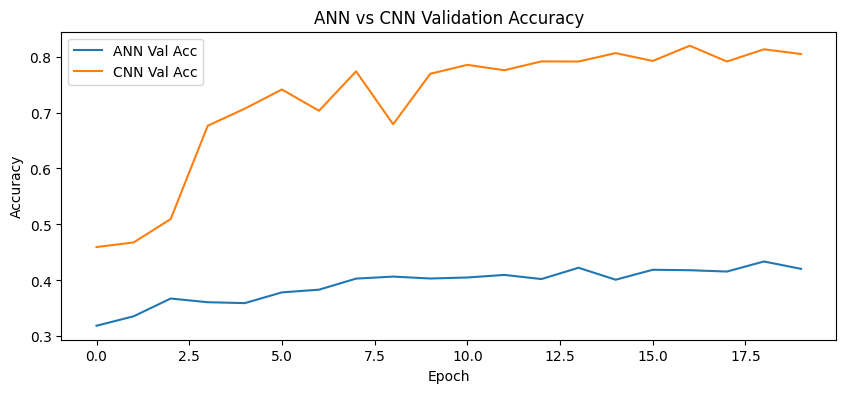

In [12]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [16]:
# -------------------------------
# CNN with Data Augmentation
# -------------------------------

from tensorflow.keras.callbacks import EarlyStopping

# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Build Model
aug_cnn_model = models.Sequential([

    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    # Classification Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(10, activation='softmax')
])

# Compile
aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fresh EarlyStopping Callback
aug_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop],
    verbose=1
)

# Evaluate
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print(f"\nAugmented CNN Test Accuracy : {aug_test_acc:.4f}")
print(f"Augmented CNN Test Loss     : {aug_test_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.3117 - loss: 1.9030 - val_accuracy: 0.4452 - val_loss: 1.5288
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4144 - loss: 1.6090 - val_accuracy: 0.3750 - val_loss: 2.2824
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.4703 - loss: 1.4761 - val_accuracy: 0.5414 - val_loss: 1.2706
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5098 - loss: 1.3783 - val_accuracy: 0.5606 - val_loss: 1.3962
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5415 - loss: 1.2981 - val_accuracy: 0.5728 - val_loss: 1.2082
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5644 - loss: 1.2384 - val_accuracy: 0.6430 - val_loss: 1.0541
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5847 - loss: 1.1894 - val_accuracy: 0.6460 - val_loss: 1.0098
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.6028 - loss: 1.1405 - 

# 📊 Final Comparison Table

In [17]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        round(ann_test_acc, 4),
        round(cnn_test_acc, 4),
        round(aug_test_acc, 4)
    ]
})

comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Test Accuracy
0,CNN,0.8064
1,CNN + Data Augmentation,0.6934
2,ANN,0.4371


In [18]:
print("="*50)
print("PROJECT SUMMARY")
print("="*50)

print(f"ANN Accuracy                : {ann_test_acc:.4f}")
print(f"CNN Accuracy                : {cnn_test_acc:.4f}")
print(f"CNN + Data Augmentation     : {aug_test_acc:.4f}")

best = max([
    ("ANN", ann_test_acc),
    ("CNN", cnn_test_acc),
    ("CNN + Data Augmentation", aug_test_acc)
], key=lambda x: x[1])

print(f"\n🏆 Best Performing Model : {best[0]}")
print(f"🏆 Best Accuracy         : {best[1]:.4f}")

PROJECT SUMMARY
ANN Accuracy                : 0.4371
CNN Accuracy                : 0.8064
CNN + Data Augmentation     : 0.6934

🏆 Best Performing Model : CNN
🏆 Best Accuracy         : 0.8064


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**